In [26]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

import torch

from notebook_utils.embedding_helpers import (
    load_encoded_latents,
    timepoint_decoder_metrics,
)
from simulation_encoder.models.model_retrieval import load_models
from simulation_encoder.loaders.loader_retrieval import load_loaders

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
""" Utility functions"""
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

def permutation_importance_aggregated_temporal(model, test_loader, baseline_score, criterion, num_iterations=1):
    model.to(device)
    model.eval()
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            embedding = model.encode(images.to(device))
            all_embeddings.append(embedding.cpu())
            all_labels.append(labels)
    
    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_labels = torch.cat(all_labels, dim=0).long()
    
    num_features = all_embeddings.size(1)
    importance_scores = torch.zeros(num_features)
    
    for _ in range(num_iterations):
        iter_scores = torch.zeros(num_features)
        for feature_idx in range(num_features):
            perm = torch.randperm(all_embeddings.size(0))
            permuted_embeddings = all_embeddings.clone()
            permuted_embeddings[:, feature_idx] = all_embeddings[perm, feature_idx]
        
            permuted_logits = model.decode_timepoint(permuted_embeddings.to(device))
            permuted_score = criterion(permuted_logits, all_labels)
            importance = permuted_score - baseline_score
            iter_scores[feature_idx] = importance
    
        importance_scores += torch.Tensor(iter_scores)
    importance_scores /= num_iterations

    return sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)

def permutation_importance_aggregated_spatial(model, test_loader, baseline_score, criterion, num_iterations=1):
    model.to(device)
    model.eval()

    all_embeddings = []
    all_images = []
    
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            embedding = model.encode(images.to(device))
            all_embeddings.append(embedding.cpu())
            all_images.append(images.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_images = torch.cat(all_images, dim=0).squeeze()

    num_features = all_embeddings.size(1)
    importance_scores = torch.zeros(num_features, dtype=torch.float16)
    
    model.cpu()
    torch.mps.empty_cache()
    with torch.no_grad():
        for _ in range(num_iterations):
            iter_scores = torch.zeros(num_features)
            for feature_idx in range(num_features):
                perm = torch.randperm(all_embeddings.size(0))
                permuted_embeddings = all_embeddings.clone()
                permuted_embeddings[:, feature_idx] = all_embeddings[perm, feature_idx]

                permuted_preds = model.decode_image(permuted_embeddings).squeeze()
                permuted_score = criterion(permuted_preds, all_images).item()
                importance = permuted_score - baseline_score
                iter_scores[feature_idx] = importance
            
            importance_scores += torch.Tensor(iter_scores)
        importance_scores /= num_iterations

    return sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)

def visualize_feature_tuning(model, latent_sample, feature_idx, variation_range=(-3, 3), steps=7):    
    half_steps = steps // 2
    feature_values = torch.linspace(variation_range[0], variation_range[1], steps)

    fig, axes = plt.subplots(1, steps, figsize=(3 * steps, 3))
    
    with torch.no_grad():
        original_image = model.decode_image(latent_sample).squeeze().detach().cpu().numpy()
        
        for col, val in enumerate(feature_values):
            modified_latent = latent_sample.clone().squeeze()
            
            if col == half_steps:
                image_to_plot = original_image
                # title = "Original"
                cmap = 'gray'
                vmin = vmax = None
            else:
                modified_latent[feature_idx] += val
                modified_image = model.decode_image(modified_latent.unsqueeze(0)).squeeze().detach().cpu().numpy()

                diff_image = modified_image - original_image
                image_to_plot = diff_image
                # title = f"{val.item():+.2f}"
                cmap = 'RdBu'
                vmax = np.max(np.abs(diff_image))
                vmin = -vmax
            
            axes[col].imshow(image_to_plot, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[col].axis('off')
    
    fig.savefig(f"figures/feature_tuning/feature_tuning_{model.name}_{latent_sample.size(1)}-{feature_idx}.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [28]:
study_name = "architecture-gastruloid"
image_dir = "data"
data_type = "gastruloid"

if data_type == "arcade":
    seq_len = 15
elif data_type == "gastruloid":
    seq_len = 9
elif data_type == "nasa":
    seq_len = 3
else:
    raise ValueError(f"Unknown data type: {data_type}")


results_dir = f"results/{study_name}"
all_models = load_models(results_dir, num_timepoints=seq_len, best_models_flag=True)
all_models = dict(sorted(all_models.items()))

all_loaders = load_loaders(results_dir, image_dir)
all_loaders = dict(sorted(all_loaders.items()))

data_loaders = {}
for dataset_name, loader in all_loaders.items():
    data_loaders[dataset_name] = {
        "train": loader.get_dataloader("train"),
        "test": loader.get_dataloader("test"),
        "full": loader,
    }

Loading model ae_small (1.96e+07 parameters)
Loading model cae_small (1.99e+07 parameters)
Loading model vit_small (2.03e+07 parameters)
Loading model neuralop_small (2.00e+07 parameters)


array2_303


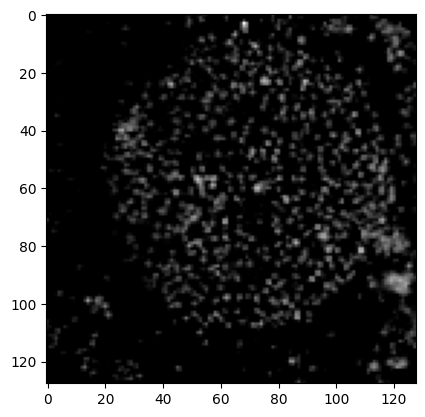

In [29]:
import random

index = None
random_samples = defaultdict(lambda: defaultdict(list))
for model_name, dataset in all_models.items():
    for dataset_name, encoder_model in dataset.items():
        loader = all_loaders[dataset_name]
        test_loader = loader.get_dataloader('test')
        dataset = test_loader.dataset
        if not index:
            index = random.randint(0, len(dataset) - 1)
        sample_image, timepoint = dataset[index]
        sample_image = sample_image.unsqueeze(0)
        random_samples[model_name][dataset_name] = sample_image

        test_idx = loader._test_indices[index]
        sample_id = loader._get_data_feature(test_idx, "sample_id")
print(sample_id)
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.show()

# Timepoint

In [30]:
log_loss = torch.nn.CrossEntropyLoss(reduction='mean')

accuracies = defaultdict(lambda: defaultdict(float))

nn_embeddings = load_encoded_latents(
    results_dir,
    all_models,
    split="test",
    normalize=False,
)

tp_from_z = timepoint_decoder_metrics(
    all_models,
    data_loaders,
    nn_embeddings,
    split="test",
    device=device,
)

for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        m = tp_from_z[model_name][dataset_name]
        accuracies[model_name][dataset_name] = m["cross_entropy"]
        print(
            f"{model_name} | {dataset_name}: accuracy={m['accuracy']:.4f} "
            f"(decode_timepoint on cached latents), CE={m['cross_entropy']:.4f}"
        )


ae | gastruloid_128: accuracy=0.0965 (decode_timepoint on cached latents), CE=3.3889
cae | gastruloid_128: accuracy=0.1106 (decode_timepoint on cached latents), CE=3.1915
neuralop | gastruloid_128: accuracy=0.1062 (decode_timepoint on cached latents), CE=4.6498
vit | gastruloid_128: accuracy=0.0986 (decode_timepoint on cached latents), CE=3.5938


In [ ]:
num_iterations = 1
top_temporal_features = defaultdict(lambda: defaultdict(list))
for model_name, dataset in all_models.items():
    print(f"Model: {model_name}")
    for dataset_name, model in dataset.items():
        loader = all_loaders[dataset_name]
        test_loader = loader.get_dataloader("test")

        baseline_acc = accuracies[model_name][dataset_name]
        feature_importances = permutation_importance_aggregated_temporal(
                    model, test_loader, baseline_acc, log_loss, num_iterations
                )
        top_temporal_features[model_name][dataset_name] = feature_importances
        print(f"Averaged feature importances (over {num_iterations} iterations):")
        for idx, imp in feature_importances:
            print(f"\tLatent dimension {idx}: importance = {imp:.4f}")

In [ ]:
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        print(model_name)
        most_important_features = top_temporal_features[model_name][dataset_name][0][0]
        print(f"most important features: {most_important_features}")
        image = random_samples[model_name][dataset_name]

        model.eval()
        model.to(device)
        with torch.no_grad():
            image = image.to(device)
            embedding = model.encode(image)

            visualize_feature_tuning(
                model, embedding, most_important_features, variation_range=(-3, 3), steps=3
            )
        model.cpu()
                

### Spatial loss feature importance

In [ ]:
"""Baseline loss calculation"""
mse_loss = torch.nn.MSELoss(reduction='mean')

s_accuracies = defaultdict(lambda: defaultdict(list))
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        loader = all_loaders[dataset_name]
        test_loader = loader.get_dataloader("test")
        y_true_list, y_pred_list = [], []

        model.to(device)
        model.eval()
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                embedding = model.encode(images)
                image_pred = model.decode_image(embedding)

                y_true_list.append(images)
                y_pred_list.append(image_pred)
        model.cpu()

        y_true = torch.cat(y_true_list, dim=0)
        y_pred = torch.cat(y_pred_list, dim=0)
        baseline_acc = mse_loss(y_pred, y_true).item()
        s_accuracies[model_name][dataset_name] = baseline_acc
        print(f"Baseline accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

In [ ]:
"""Feature importance"""
# num_iterations = 1
# top_spatial_features = defaultdict(lambda: defaultdict(list))
# for model_name, dataset in all_models.items():
#     for dataset_name, model in dataset.items():
#         loader = all_loaders[dataset_name]
#         test_loader = loader.get_dataloader("test")

#         baseline_acc = accuracies[model_name][dataset_name]
#         feature_importances = permutation_importance_aggregated_spatial(
#             model, test_loader, baseline_acc, mse_loss, num_iterations
#         )
#         top_spatial_features[model_name][dataset_name] = feature_importances
#         print(f"Averaged feature importances (over {num_iterations} iterations):")
#         for idx, imp in feature_importances:
#             print(f"\tLatent dimension {idx}: importance = {imp:.4f}")

In [ ]:
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        most_important_features = top_temporal_features[model_name][dataset_name][0][0]
        image = random_samples[model_name][dataset_name]

        model.to(device)
        model.eval()
        with torch.no_grad():
            image = image.to(device)
            embedding = model.encode(image)
            visualize_feature_tuning(
                model, embedding, most_important_features, variation_range=(-3, 3), steps=7
            )
        model.cpu()

# All dimensions

In [ ]:
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        print(f"Model: {model_name}")
        image = random_samples[model_name][dataset_name]

        model.to(device)
        model.eval()
        with torch.no_grad():
            image = image.to(device)
            embedding = model.encode(image)
            num_dims = embedding.shape[1]
            for i in range(num_dims):
                visualize_feature_tuning(
                    model, embedding, feature_idx=i, variation_range=(-3, 3), steps=7
                )
        model.cpu()